In [1]:
# Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.20.0


In [6]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [7]:
import zipfile
import os

zip_file = "archive (3).zip"
extract_path = "/content/paddy_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import os

dataset_path = "/content/paddy_dataset"

for root, dirs, files in os.walk(dataset_path):
    if files:
        print(root, "->", len(files), "files")

/content/paddy_dataset/rice_leaf_diseases/Brown spot -> 40 files
/content/paddy_dataset/rice_leaf_diseases/Leaf smut -> 40 files
/content/paddy_dataset/rice_leaf_diseases/Bacterial leaf blight -> 40 files


In [9]:
import os

dataset_path = "/content/paddy_dataset"

for root, dirs, files in os.walk(dataset_path):
    folder_name = os.path.basename(root).lower()

    if "narrow" in folder_name or "brown" in folder_name:
        print("Folder:", root)
        print("Number of images:", len(files))

Folder: /content/paddy_dataset/rice_leaf_diseases/Brown spot
Number of images: 40


In [11]:
import os

for root, dirs, files in os.walk("/content/paddy_dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-" * 50)

Folder: /content/paddy_dataset
Subfolders: ['rice_leaf_diseases']
Files: 0
--------------------------------------------------
Folder: /content/paddy_dataset/rice_leaf_diseases
Subfolders: ['Brown spot', 'Leaf smut', 'Bacterial leaf blight']
Files: 0
--------------------------------------------------
Folder: /content/paddy_dataset/rice_leaf_diseases/Brown spot
Subfolders: []
Files: 40
--------------------------------------------------
Folder: /content/paddy_dataset/rice_leaf_diseases/Leaf smut
Subfolders: []
Files: 40
--------------------------------------------------
Folder: /content/paddy_dataset/rice_leaf_diseases/Bacterial leaf blight
Subfolders: []
Files: 40
--------------------------------------------------


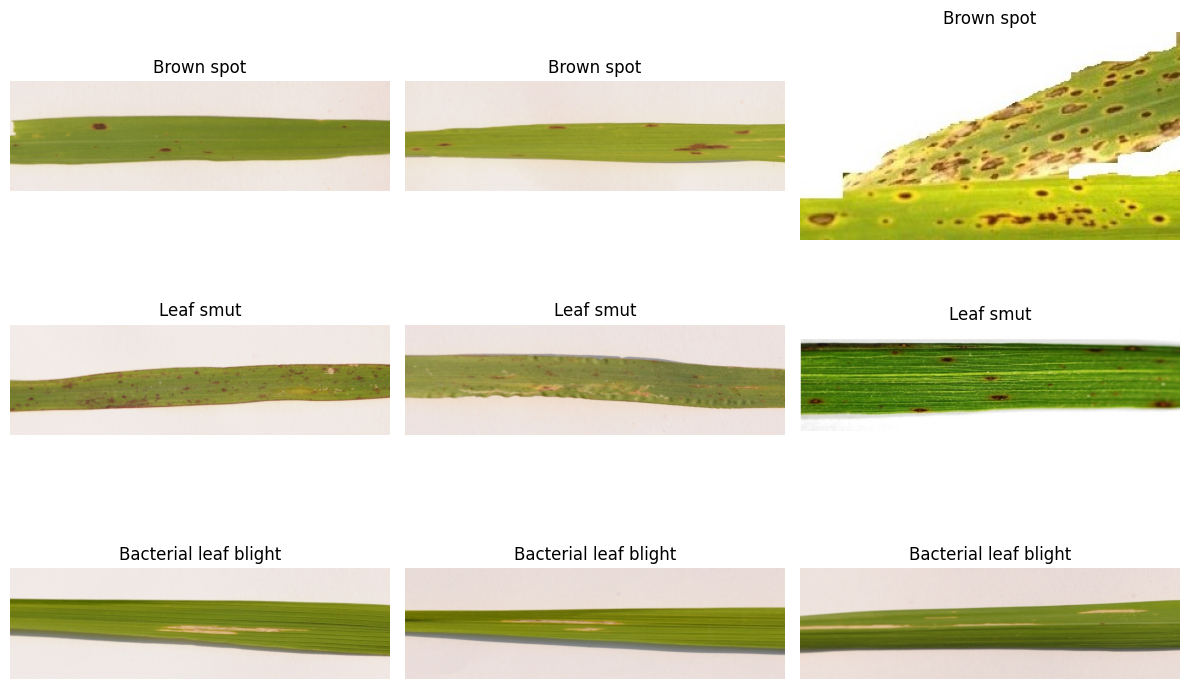

In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/paddy_dataset/rice_leaf_diseases"

classes = ["Brown spot", "Leaf smut", "Bacterial leaf blight"]

plt.figure(figsize=(12, 8))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for image_file in image_files[:3]:
        image_path = os.path.join(class_path, image_file)
        image = Image.open(image_path)

        plt.subplot(3, 3, plot_index)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/paddy_dataset/rice_leaf_diseases"

IMG_SIZE = (128, 128)
BATCH_SIZE = 8

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Classes:", train_data.class_indices)

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.
Classes: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


In [14]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu",
                           input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 440ms/step - accuracy: 0.2708 - loss: 1.3057 - val_accuracy: 0.3333 - val_loss: 1.0879
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 541ms/step - accuracy: 0.3229 - loss: 1.1132 - val_accuracy: 0.4167 - val_loss: 1.0941
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 396ms/step - accuracy: 0.3646 - loss: 1.1212 - val_accuracy: 0.6667 - val_loss: 1.0760
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 584ms/step - accuracy: 0.4688 - loss: 1.0709 - val_accuracy: 0.3333 - val_loss: 1.1760
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 423ms/step - accuracy: 0.3021 - loss: 1.1827 - val_accuracy: 0.3333 - val_loss: 1.1052
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 655ms/step - accuracy: 0.3542 - loss: 1.0902 - val_accuracy: 0.3333 - val_loss: 1.1093
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.5000 - loss: 1.0631 - val_accuracy: 0.2500 - val_loss: 1.3693
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.4479 - loss: 0.9922 - val_accuracy: 0.

In [16]:
test_loss, test_accuracy = model.evaluate(val_data)

print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5000 - loss: 0.9568
Test Accuracy: 50.00%


In [17]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 608ms/step - accuracy: 0.3438 - loss: 1.5571 - val_accuracy: 0.3750 - val_loss: 1.2548
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - accuracy: 0.6875 - loss: 0.7589 - val_accuracy: 0.7500 - val_loss: 0.6682
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.7812 - loss: 0.5237 - val_accuracy: 0.7083 - val_loss: 0.5893
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.7604 - loss: 0.4917 - val_accuracy: 0.7083 - val_loss: 0.5773
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 0.8958 - loss: 0.3784 - val_accuracy: 0.7917 - val_loss: 0.4494
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.8958 - loss: 0.3000 - val_accuracy: 0.7500 - val_loss: 0.5960
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - accuracy: 0.8854 - loss: 0.2753 - val_accuracy: 0.7917 - val_loss: 0.6061
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step - accuracy: 0.8958 - loss: 0.2620 - val_accuracy: 0

In [19]:
test_loss, test_accuracy = model.evaluate(val_data)

print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.7917 - loss: 0.6672
Test Accuracy: 79.17%


In [20]:
base_model.trainable = True

# Freeze the first layers and fine-tune the later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 566ms/step - accuracy: 0.6354 - loss: 0.9986 - val_accuracy: 0.8333 - val_loss: 0.7295
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.6354 - loss: 0.9041 - val_accuracy: 0.7917 - val_loss: 0.9567
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.7396 - loss: 0.7420 - val_accuracy: 0.7917 - val_loss: 0.6145
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 382ms/step - accuracy: 0.7500 - loss: 0.6435 - val_accuracy: 0.8333 - val_loss: 0.7126
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - accuracy: 0.7500 - loss: 0.6293 - val_accuracy: 0.8333 - val_loss: 0.8390
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.7396 - loss: 0.6668 - val_accuracy: 0.8750 - val_loss: 0.6527
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - accuracy: 0.8229 - loss: 0.4490 - val_accuracy: 0.8750 - val_loss: 0.3841
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 501ms/step - accuracy: 0.8229 - loss: 0.4311 - val_accuracy: 0

In [21]:
test_loss, test_accuracy = model.evaluate(val_data)

print("Final Test Accuracy: {:.2f}%".format(test_accuracy * 100))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.7917 - loss: 0.7492
Final Test Accuracy: 79.17%


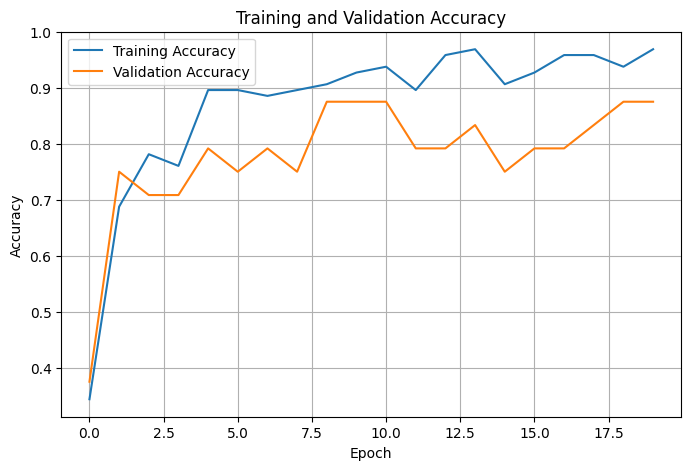

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

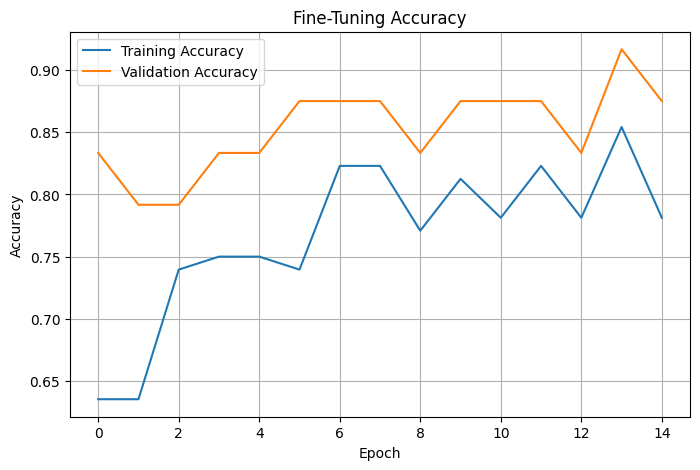

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_fine.history["accuracy"], label="Training Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Validation Accuracy")

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Upload image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Load and resize image
img = load_img(image_path, target_size=(128, 128))

# Convert image to array
img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get predicted class
predicted_class = np.argmax(prediction[0])

# Class names
class_names = list(train_data.class_indices.keys())

print("Predicted Disease:", class_names[predicted_class])
print("Confidence: {:.2f}%".format(
    prediction[0][predicted_class] * 100
))

Saving paddy.jpg to paddy.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Disease: Bacterial leaf blight
Confidence: 99.39%


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 591ms/step


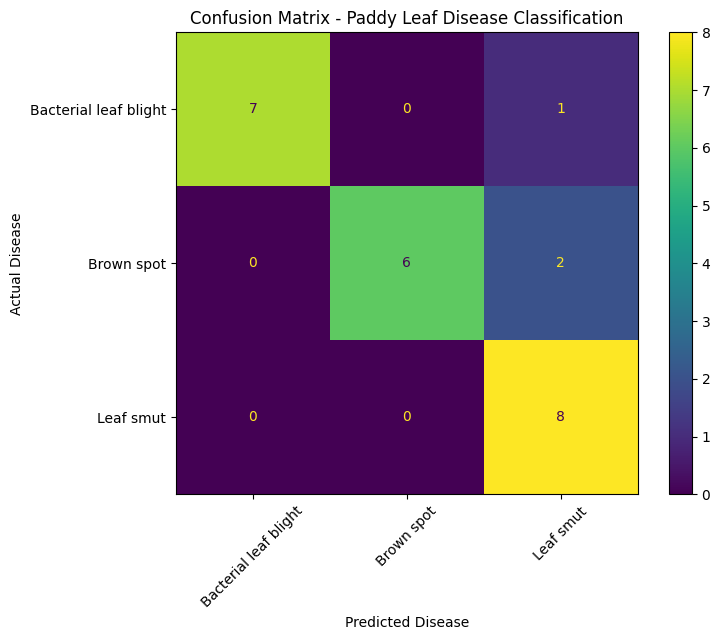

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Reset validation data
val_data.reset()

# Predict validation images
predictions = model.predict(val_data)

# Convert predictions to class numbers
y_pred = np.argmax(predictions, axis=1)

# Actual class numbers
y_true = val_data.classes

# Get class names
class_names = list(val_data.class_indices.keys())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Paddy Leaf Disease Classification")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.show()

In [27]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report")
print("=====================")
print(report)

Classification Report
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.88      0.93         8
           Brown spot       1.00      0.75      0.86         8
            Leaf smut       0.73      1.00      0.84         8

             accuracy                           0.88        24
            macro avg       0.91      0.88      0.88        24
         weighted avg       0.91      0.88      0.88        24



In [28]:
loss, accuracy = model.evaluate(val_data, verbose=0)
print(f"Final Accuracy: {accuracy * 100:.2f}%")

Final Accuracy: 87.50%
